In [ ]:
print("Halo Dunia")

Halo Dunia


In [ ]:
import yfinance as yf
tickers = ["BBCA.JK", "BBRI.JK", "BBNI.JK"]
data = yf.download(tickers, start="2019-01-01", end="2025-12-31")
print(data.shape)

/tmp/ipykernel_1720/776339029.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2019-01-01", end="2025-12-31")
[*********************100%***********************]  3 of 3 completed

(1705, 15)


In [ ]:
returns = data['Close'].pct_change().dropna()
print(returns.head())
print(returns.shape)

Ticker       BBCA.JK   BBNI.JK   BBRI.JK
Date                                    
2019-01-02  0.007692 -0.008523 -0.013661
2019-01-03 -0.011451  0.000000  0.002770
2019-01-04  0.004827  0.000000  0.011050
2019-01-07  0.007685  0.017192  0.000000
2019-01-08 -0.000953  0.002817  0.005465
(1704, 3)


In [ ]:
expected_returns = returns.mean() *252
volatilities = returns.std() * (252**0.5)

print("Expected Annual Returns:")
print(expected_returns)
print("\nAnnualized Volatility:")
print(volatilities)

Expected Annual Returns:
Ticker
BBCA.JK    0.119304
BBNI.JK    0.094133
BBRI.JK    0.121956
dtype: float64

Annualized Volatility:
Ticker
BBCA.JK    0.249410
BBNI.JK    0.340139
BBRI.JK    0.325242
dtype: float64


In [ ]:
cov_matrix = returns.cov() * 252
print(cov_matrix)

Ticker    BBCA.JK   BBNI.JK   BBRI.JK
Ticker                               
BBCA.JK  0.062205  0.046189  0.045316
BBNI.JK  0.046189  0.115694  0.075865
BBRI.JK  0.045316  0.075865  0.105783


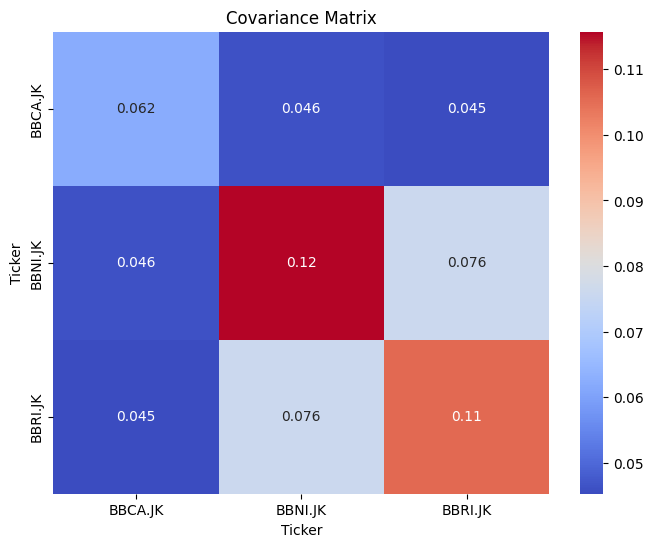

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm')
plt.title('Covariance Matrix')
plt.show()

In [ ]:
import numpy as np

num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios) :
  weights = np.random.random(3)
  weights /= np.sum(weights)
  weights_record.append(weights)

  portfolio_return = np.dot(weights, expected_returns)
  portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
  sharpe_ratio = portfolio_return / portfolio_volatility

  results[0, i] = portfolio_return
  results[1, i] = portfolio_volatility
  results[2, i] = sharpe_ratio

print("Selesai Generate", num_portfolios, "portofolio")

Selesai Generate 5000 portofolio


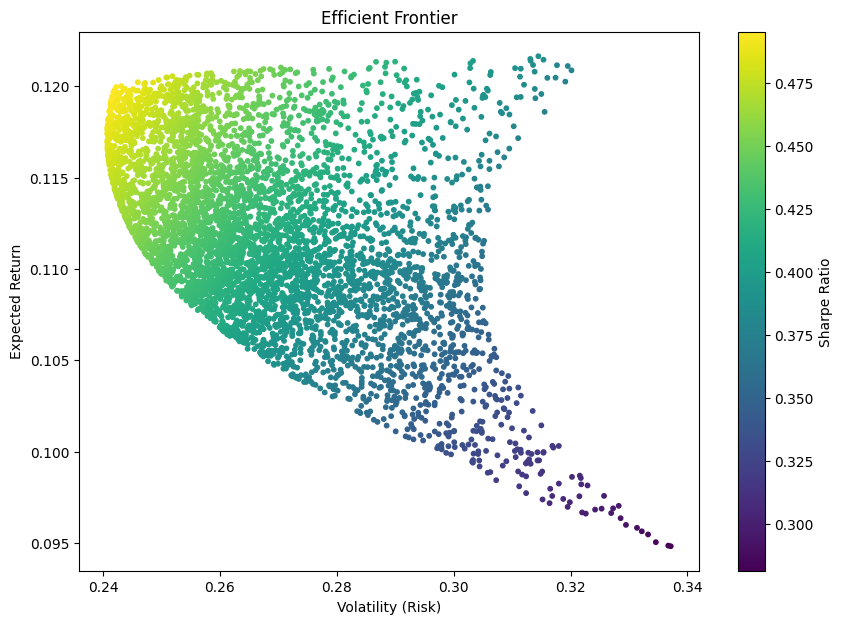

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', marker='o', s=10,)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.show()


In [ ]:
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]

min_vol_idx = np.argmin(results[1])
min_vol_return = results[0, min_vol_idx]
min_vol_volatility = results[1, min_vol_idx]

print("Max Sharpe Ratio Portfolio:")
print("Expected Return:", max_sharpe_return)

print("\nMinimum Volatility Portfolio:")
print("Expected Return:", min_vol_return)


Max Sharpe Ratio Portfolio:
Expected Return: 0.11996076663957482

Minimum Volatility Portfolio:
Expected Return: 0.11696383837023733


In [ ]:
max_sharp_idx = np.argmax(results[2])
optimal_weights = weights_record[max_sharp_idx]

print("Bobot Optimal (Max Sharpe Ratio)")
print("BBCA:", optimal_weights[0])
print("BBRI:", optimal_weights[1])
print("BBNI:", optimal_weights[2])

Bobot Optimal (Max Sharpe Ratio)
BBCA: 0.7596525914358084
BBRI: 0.0013883927894380932
BBNI: 0.23895901577475348
